Best params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}
Accuracy: 0.7304
Precision: 0.7595509383378016
Recall: 0.6661278471711977
F1: 0.7097784388945432
Confusion matrix:
 [[5510 1435]
 [2272 4533]]
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6945
           1       0.76      0.67      0.71      6805

    accuracy                           0.73     13750
   macro avg       0.73      0.73      0.73     13750
weighted avg       0.73      0.73      0.73     13750



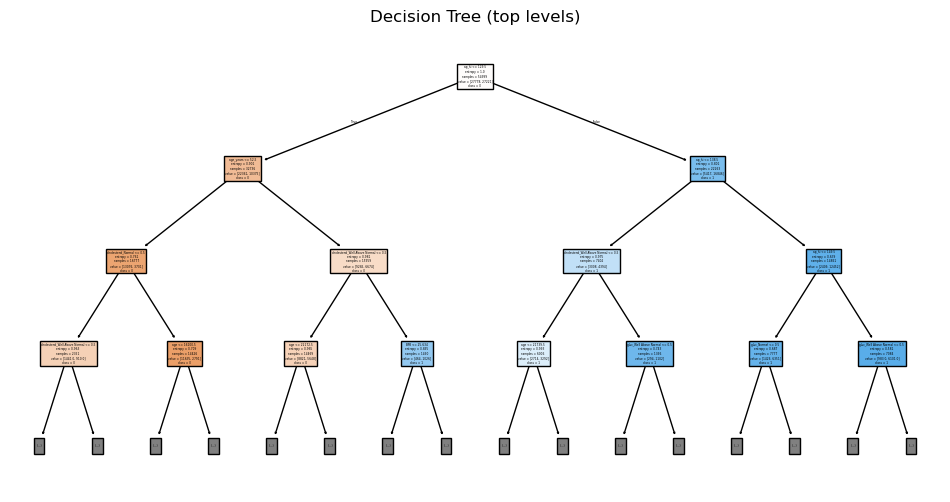

In [1]:
# 2 - DECISION TREE 
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("processed_cardio_dataset.csv", sep=None, engine='python')
if 'id' in df.columns: df = df.drop('id', axis=1)
df = df.replace({True:1, False:0})
label_col = 'cardio'

X = df.drop(label_col, axis=1)
y = df[label_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Decision tree does not require scaling
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini','entropy'],
    'max_depth': [3,5,7,10,None],
    'min_samples_leaf': [1,2,5,10]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(dt, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
best_dt = grid.best_estimator_

# Evaluate
def eval_dt(model):
    ypred = model.predict(X_test)
    print("Best params:", grid.best_params_)
    print("Accuracy:", accuracy_score(y_test, ypred))
    print("Precision:", precision_score(y_test, ypred, zero_division=0))
    print("Recall:", recall_score(y_test, ypred, zero_division=0))
    print("F1:", f1_score(y_test, ypred, zero_division=0))
    print("Confusion matrix:\n", confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))
eval_dt(best_dt)

# Plot small tree (top levels)
plt.figure(figsize=(12,6))
plot_tree(best_dt, feature_names=X.columns, class_names=['0','1'], max_depth=3, filled=True)
plt.title("Decision Tree (top levels)")
plt.show()

# Notes:
# - Use Accuracy/F1/AUC. Trees are interpretable, but guard vs overfitting (use max_depth/min_samples).
